# Smart Retail & Health Analytics System

This project demonstrates data filtering, data cleaning, handling missing values, regression analysis, statistical testing, and visualization using an integrated dataset.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm

## Data Generation

A synthetic dataset is created representing customer, sales, and health attributes.

In [22]:
np.random.seed(42)

data = pd.DataFrame({
    "Age": np.random.randint(20, 70, 100),
    "Quantity": np.random.randint(1, 10, 100),
    "Price": np.random.randint(100, 500, 100),
    "Cholesterol": np.random.randint(150, 300, 100),
    "BP": np.random.randint(80, 180, 100),
    "Disease": np.random.randint(0, 2, 100)
})

data["Revenue"] = data["Quantity"] * data["Price"]

data.head()

,Age,Quantity,Price,Cholesterol,BP,Disease,Revenue
0,58,9,302,258,96,1,2718
1,48,8,283,200,142,1,2264
2,34,1,222,157,98,0,222
3,62,8,354,176,171,1,2832
4,27,8,393,176,137,1,3144


## Data Filtering

Filtering transactions where revenue is greater than 2000.

In [24]:
high_revenue = data[data["Revenue"] > 2000]
high_revenue.head()

,Age,Quantity,Price,Cholesterol,BP,Disease,Revenue
0,58,9,302,258,96,1,2718
1,48,8,283,200,142,1,2264
3,62,8,354,176,171,1,2832
4,27,8,393,176,137,1,3144
7,38,8,471,246,169,1,3768


## Handling Missing Values

Missing values are introduced and replaced using the mean of the column.

In [26]:
data.loc[0:5, "Price"] = np.nan
data["Price"] = data["Price"].fillna(data["Price"].mean())

data.isnull().sum()

Age            0
Quantity       0
Price          0
Cholesterol    0
BP             0
Disease        0
Revenue        0
dtype: int64

## Data Cleaning

Removing rows with missing values to ensure clean dataset.

In [28]:
cleaned_data = data.dropna()
cleaned_data.shape

(100, 7)

## Correlation Analysis

A heatmap is used to visualize relationships between variables.

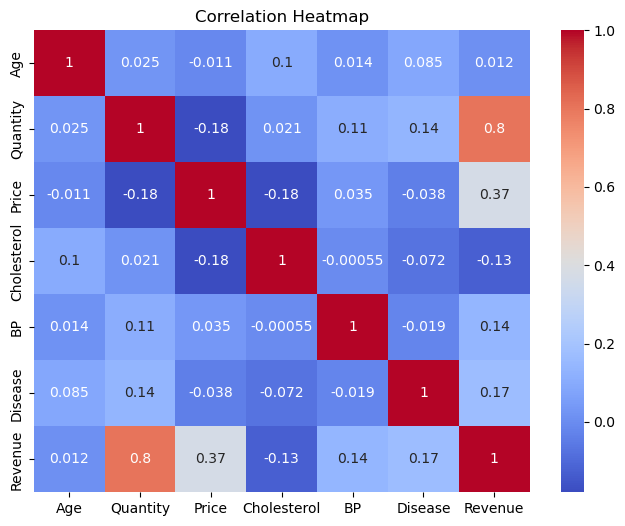

In [30]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Logistic Regression

Predicting disease based on health attributes.

In [32]:
X = data[["Age", "Cholesterol", "BP"]]
y = data["Disease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

print("Accuracy:", log_model.score(X_test, y_test))

Accuracy: 0.45


## Linear Regression

Analyzing revenue trend over time.

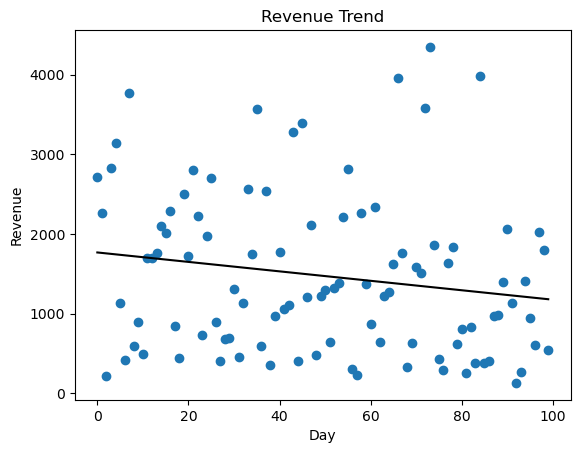

In [39]:
data["Day"] = np.arange(len(data))

X_lr = data[["Day"]]
y_lr = data["Revenue"]

lin_model = LinearRegression()
lin_model.fit(X_lr, y_lr)

plt.scatter(X_lr, y_lr)
plt.plot(X_lr, lin_model.predict(X_lr), color='black')
plt.title("Revenue Trend")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.show()

## NumPy Operations

Calculating statistical measures.

In [41]:
sales = np.array(data["Revenue"])

print("Mean:", np.mean(sales))
print("Sum:", np.sum(sales))
print("Standard Deviation:", np.std(sales))

Mean: 1475.31
Sum: 147531
Standard Deviation: 1001.5219188315351


## Z-Test

Performing hypothesis testing.

In [43]:
sample = np.random.normal(150, 10, 40)

sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)

z_score = (sample_mean - 140) / (sample_std / np.sqrt(40))
critical_z = norm.ppf(0.95)

print("Z-Score:", z_score)
print("Critical Value:", critical_z)

Z-Score: 6.854935319786846
Critical Value: 1.6448536269514722


## Financial Analysis

Simulating returns and evaluating risk.

In [47]:
returns = np.random.normal(0.001, 0.01, (252, 3))

print("Average Return:", np.mean(returns))
print("Risk:", np.std(returns))

Average Return: 0.0019345643348812548
Risk: 0.010742148404741714


## Sales Analysis

Analyzing revenue and relationship between quantity and price.

Total Revenue: 154628


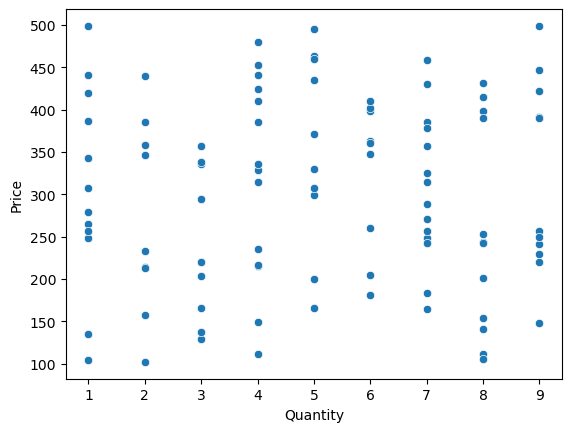

In [49]:
sales_df = pd.DataFrame({
    "Quantity": np.random.randint(1, 10, 100),
    "Price": np.random.randint(100, 500, 100)
})

sales_df["Revenue"] = sales_df["Quantity"] * sales_df["Price"]

print("Total Revenue:", sales_df["Revenue"].sum())

sns.scatterplot(x="Quantity", y="Price", data=sales_df)
plt.show()

## Conclusion

This project demonstrates an end-to-end data science workflow including data preprocessing, visualization, machine learning, and statistical analysis.